In [2]:
import os
import sys
path = os.getcwd()
while True:
    if 'utils.py' in os.listdir(path):
        if path not in sys.path:
            sys.path.append(path)
        break
    new_path = os.path.dirname(path)
    if new_path == path:
        upload_utils = files.upload()
        break
    path = new_path

import utils

/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Mistral_7B_Instruct_v0.3/Results/checkpoint_scitail_Mistral_7B_Instruct_v0.3_4bit_zero_shot.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Mistral_7B_Instruct_v0.3/Results/checkpoint_scitail_Mistral_7B_Instruct_v0.3_4bit_few_shot_1_examples_entails.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Mistral_7B_Instruct_v0.3/Results/checkpoint_scitail_Mistral_7B_Instruct_v0.3_4bit_few_shot_1_examples_neutral.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Mistral_7B_Instruct_v0.3/Results/checkpoint_scitail_Mistral_7B_Instruct_v0.3_4bit_few_shot_2_examples.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Mistral_7B_Instruct_v0.3/Re

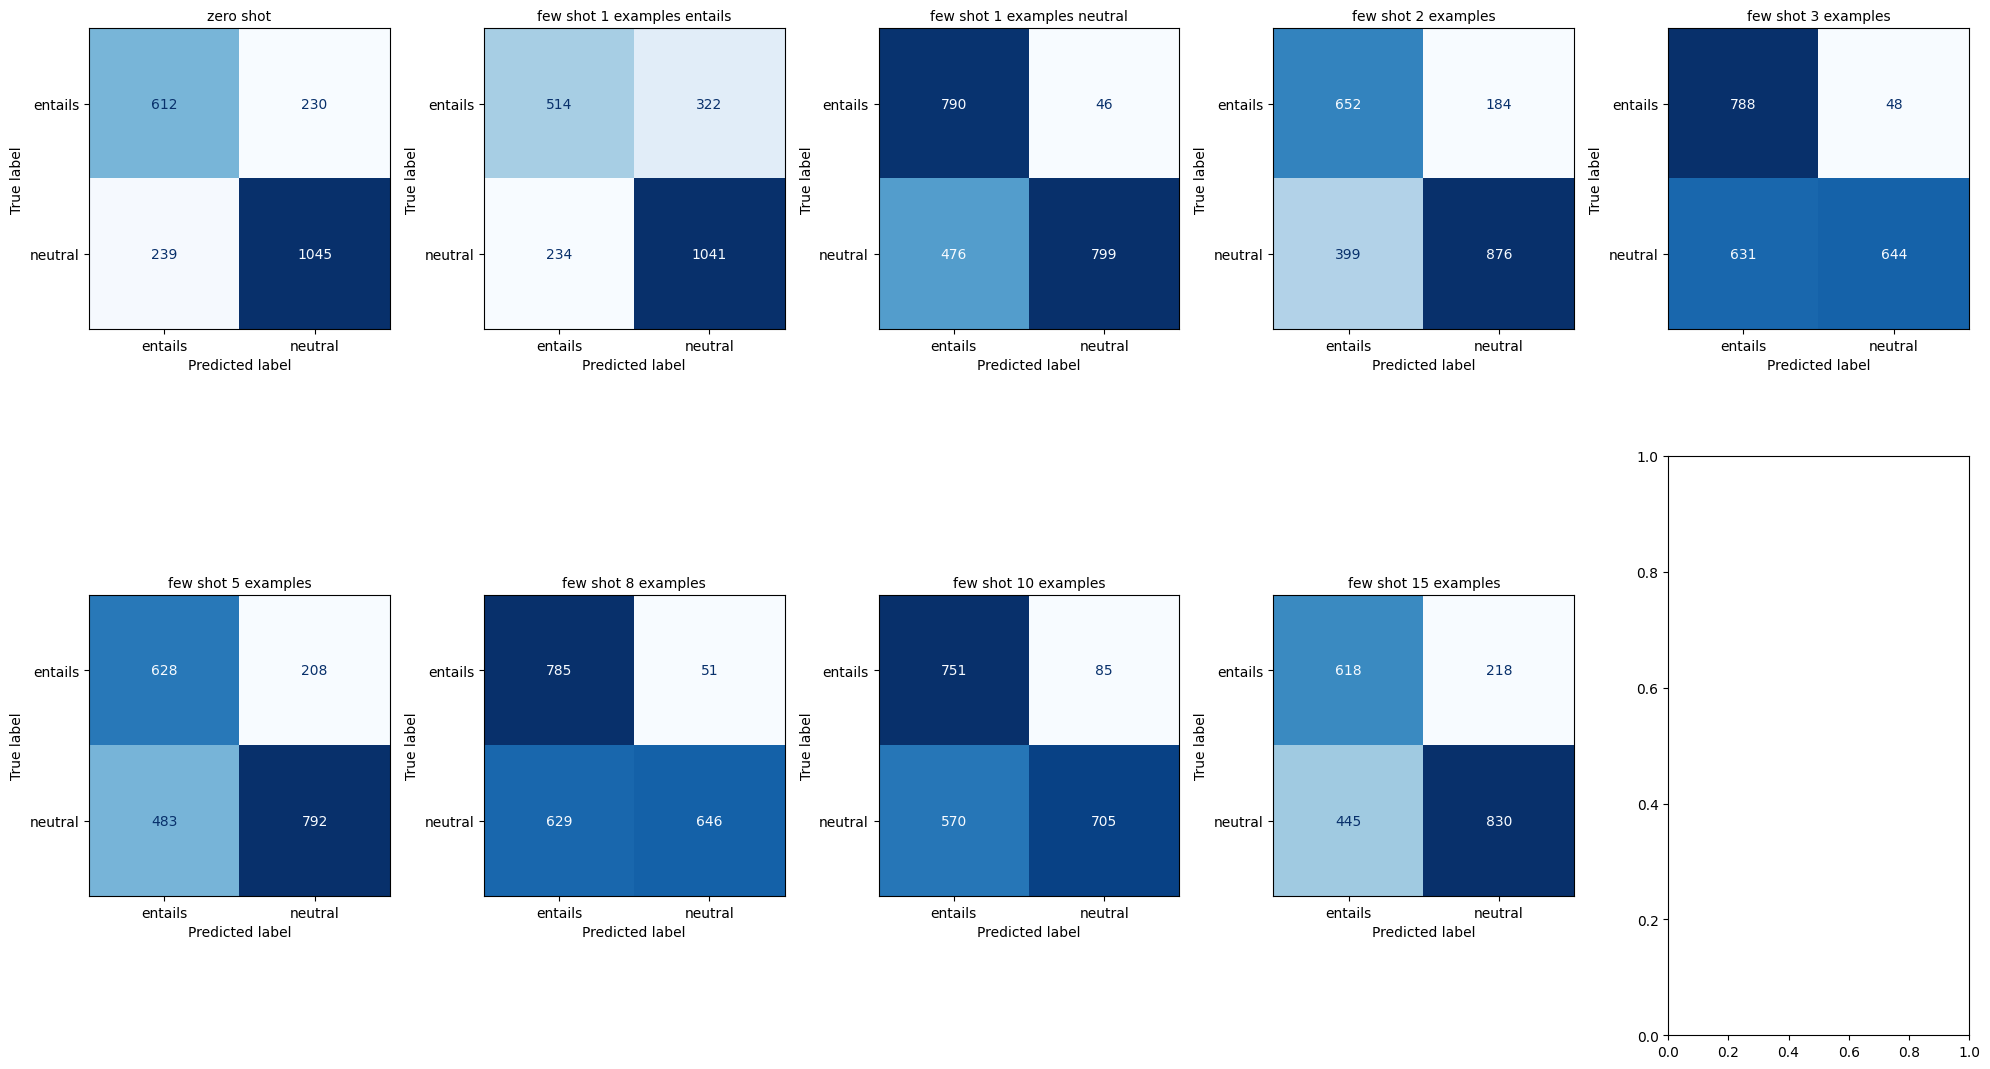

In [3]:
import matplotlib.pyplot as plt

training_modes = [
    'zero shot',
    'few shot 1 examples entails',
    'few shot 1 examples neutral',
    'few shot 2 examples',
    'few shot 3 examples',
    'few shot 5 examples',
    'few shot 8 examples',
    'few shot 10 examples',
    'few shot 15 examples'    
]

fig, axes = plt.subplots(2, 5, figsize=(20,12))
axes = axes.flatten()
accs, precisions, recalls, f1s, mccs, kappas = [], [], [], [], [], []

for idx, mode in enumerate(training_modes):
    global_params = {
            'dataset_type': 'scitail',
            'quantization': '4bit',
            'training_mode': mode,
            'model_id': 'mistralai/Mistral-7B-Instruct-v0.3'}
   
    checkpoint_path = utils.create_checkpoint_path(params=global_params)
    predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)

    acc, precision, recall, f1, mcc, kappa = utils.get_metrics(
                                            predicted_labels=predicted_labels,
                                            gold_labels=gold_labels,
                                            params=global_params,
                                            ax=axes[idx]
                                            )   
    accs.append(round(acc, 4))
    precisions.append(round(precision, 4))
    recalls.append(round(recall, 4))
    f1s.append(round(f1, 4))
    mccs.append(round(mcc, 4))
    kappas.append(round(kappa, 4))

plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
labels = [
    "0 examples",
    "1 example (entails)",
    "1 example (neutral)",
    "2 examples",
    "3 examples",
    "5 examples",
    "8 examples",
    "10 examples",
    "15 examples"
]

metrics_df = pd.DataFrame(
    {"Accuracy": accs,
     "Precision": precisions,
     "Recalls": recalls,
     "F1": f1s,
     "MCC": mccs,
     "Kappa": kappas},
     index= labels
)
metrics_df

,Accuracy,Precision,Recalls,F1,MCC,Kappa
0 examples,0.7794,0.7694,0.7704,0.7699,0.5397,0.5397
1 example (entails),0.7366,0.7255,0.7157,0.7191,0.4410,0.4393
1 example (neutral),0.7527,0.7848,0.7858,0.7527,0.5706,0.5251
2 examples,0.7238,0.7234,0.7335,0.7207,0.4568,0.4472
3 examples,0.6784,0.7430,0.7238,0.6768,0.4664,0.3997
5 examples,0.6727,0.6786,0.6862,0.6707,0.3647,0.3524
8 examples,0.6779,0.7410,0.7228,0.6765,0.4635,0.3983
10 examples,0.6897,0.7305,0.7256,0.6896,0.4561,0.4103
15 examples,0.6859,0.6867,0.6951,0.6827,0.3817,0.3728


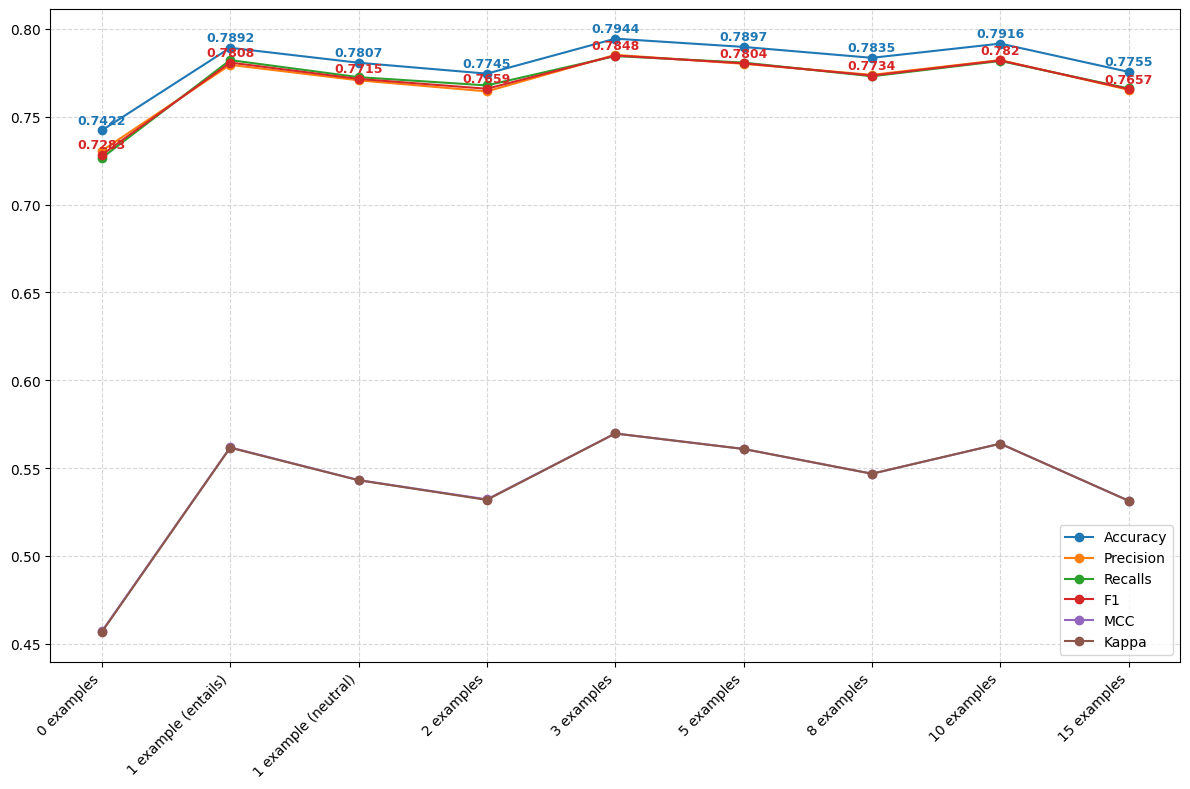

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

# plot all metrics
metrics_df.plot(kind='line', ax=ax, marker='o')

# set custom x-axis labels
ax.set_xticks(range(len(metrics_df.index)))
ax.set_xticklabels(metrics_df.index, rotation=45, ha='right')

# show grid
ax.grid(True, linestyle='--', alpha=0.5)

# annotate only Accuracy and F1
for metric in ["Accuracy", "F1"]:
    for x, y in enumerate(metrics_df[metric]):
        ax.text(x, y + 0.002, str(y), ha='center', va='bottom', fontsize=9, fontweight='bold', color=ax.get_lines()[list(metrics_df.columns).index(metric)].get_color())

plt.tight_layout()
plt.show()

Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Mistral_7B_Instruct_v0.3/Results/checkpoint_scitail_Mistral_7B_Instruct_v0.3_4bit_zero_shot_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Mistral_7B_Instruct_v0.3/Results/checkpoint_scitail_Mistral_7B_Instruct_v0.3_4bit_few_shot_1_examples_entails_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Mistral_7B_Instruct_v0.3/Results/checkpoint_scitail_Mistral_7B_Instruct_v0.3_4bit_few_shot_1_examples_neutral_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Mistral_7B_Instruct_v0.3/Results/checkpoint_scitail_Mistral_7B_Instruct_v0.3_4bit_few_shot_2_examples_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Noteboo

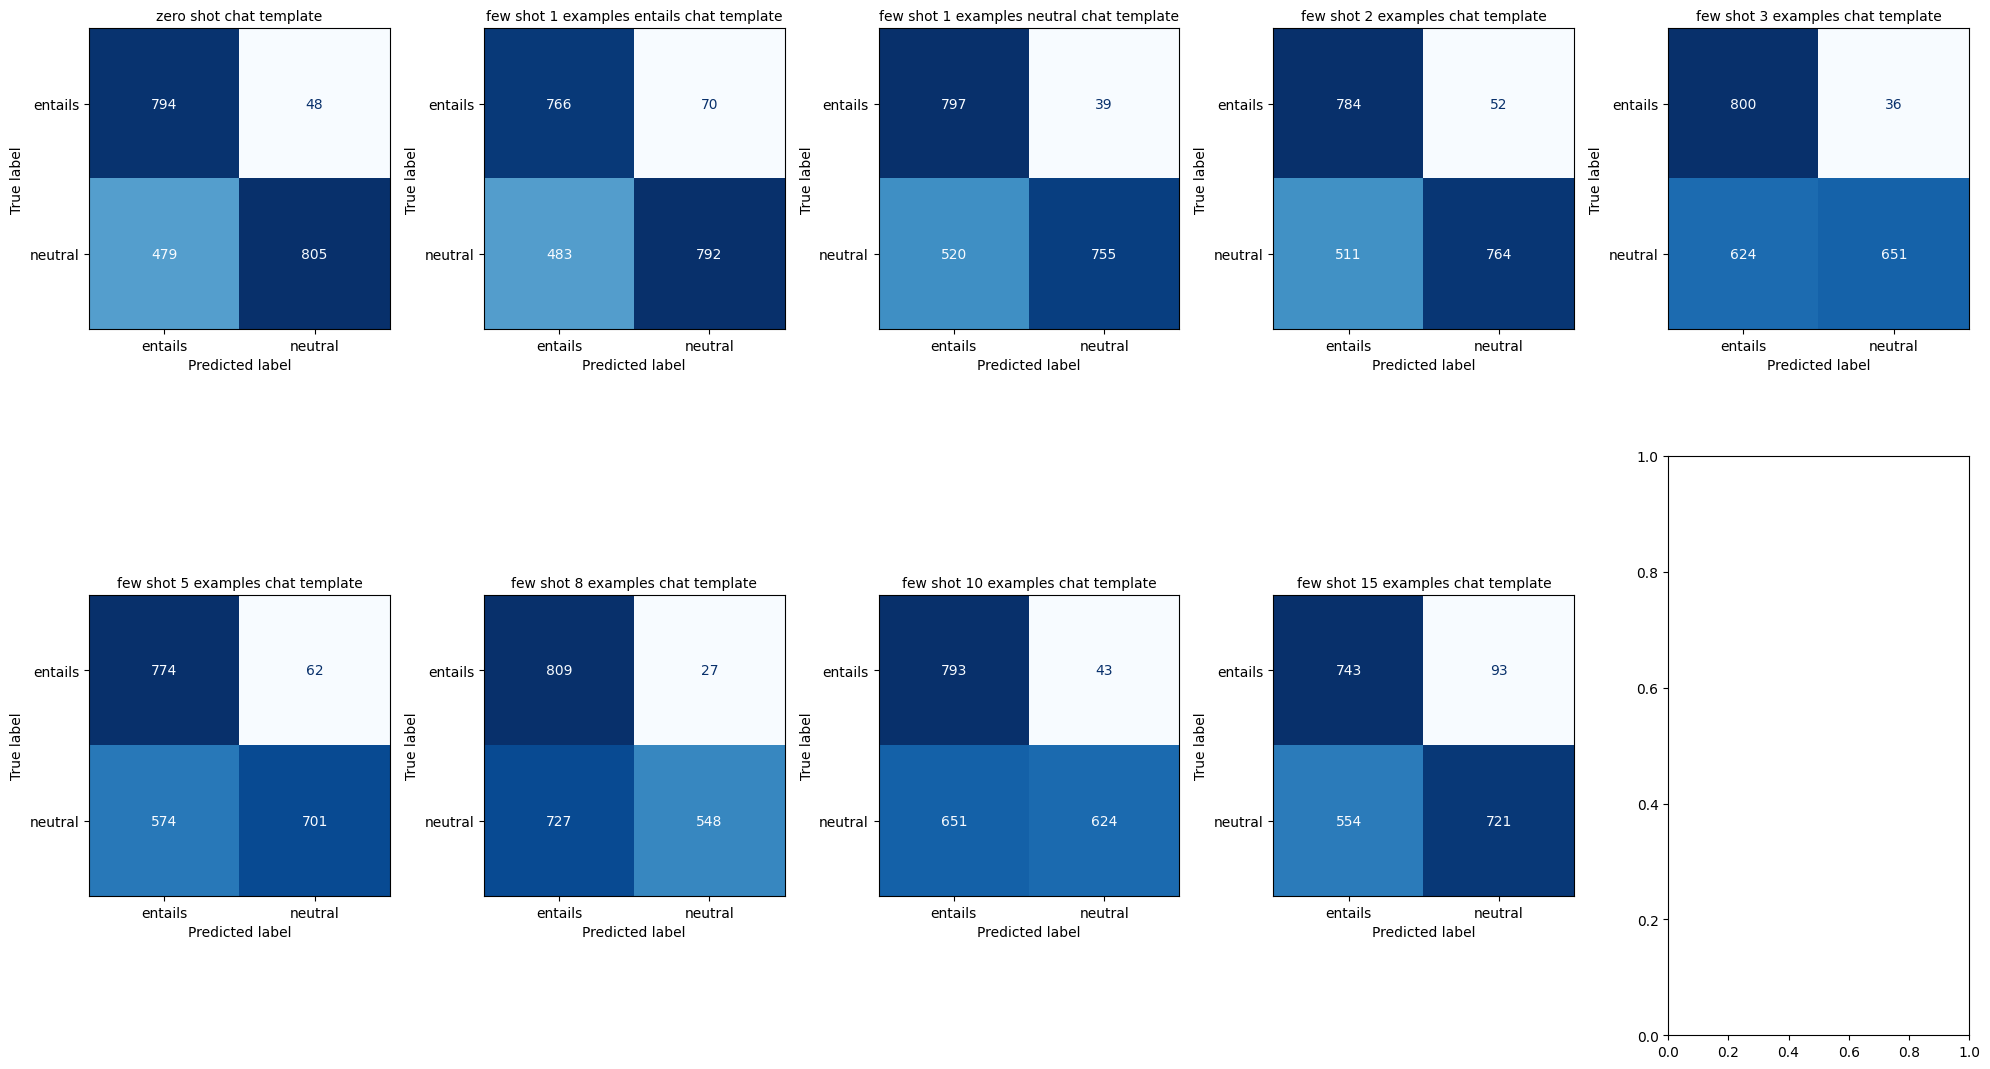

In [3]:
import matplotlib.pyplot as plt

training_modes = [
    'zero shot chat template',
    'few shot 1 examples entails chat template',
    'few shot 1 examples neutral chat template',
    'few shot 2 examples chat template',
    'few shot 3 examples chat template',
    'few shot 5 examples chat template',
    'few shot 8 examples chat template',
    'few shot 10 examples chat template',
    'few shot 15 examples chat template'    
]

fig, axes = plt.subplots(2, 5, figsize=(20,12))
axes = axes.flatten()
accs, precisions, recalls, f1s, mccs, kappas = [], [], [], [], [], []

for idx, mode in enumerate(training_modes):
    global_params = {
            'dataset_type': 'scitail',
            'quantization': '4bit',
            'training_mode': mode,
            'model_id': 'mistralai/Mistral-7B-Instruct-v0.3'}
   
    checkpoint_path = utils.create_checkpoint_path(params=global_params)
    predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)

    acc, precision, recall, f1, mcc, kappa = utils.get_metrics(
                                            predicted_labels=predicted_labels,
                                            gold_labels=gold_labels,
                                            params=global_params,
                                            ax=axes[idx]
                                            )   
    accs.append(round(acc, 4))
    precisions.append(round(precision, 4))
    recalls.append(round(recall, 4))
    f1s.append(round(f1, 4))
    mccs.append(round(mcc, 4))
    kappas.append(round(kappa, 4))

plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
labels = [
    "0 examples chat template",
    "1 example (entails) chat template",
    "1 example (neutral) chat template",
    "2 examples chat template",
    "3 examples chat template",
    "5 examples chat template",
    "8 examples chat template",
    "10 examples chat template",
    "15 examples chat template"
]

metrics_df = pd.DataFrame(
    {"Accuracy": accs,
     "Precision": precisions,
     "Recalls": recalls,
     "F1": f1s,
     "MCC": mccs,
     "Kappa": kappas},
     index= labels
)
metrics_df

,Accuracy,Precision,Recalls,F1,MCC,Kappa
0 examples chat template,0.7521,0.7837,0.7850,0.7521,0.5687,0.5238
1 example (entails) chat template,0.7380,0.7660,0.7687,0.7380,0.5348,0.4953
1 example (neutral) chat template,0.7352,0.7780,0.7728,0.7351,0.5508,0.4963
2 examples chat template,0.7333,0.7708,0.7685,0.7333,0.5393,0.4906
3 examples chat template,0.6874,0.7547,0.7338,0.6858,0.4880,0.4170
5 examples chat template,0.6987,0.7465,0.7378,0.6984,0.4842,0.4303
8 examples chat template,0.6428,0.7399,0.6988,0.6373,0.4367,0.3474
10 examples chat template,0.6712,0.7424,0.7190,0.6691,0.4607,0.3892
15 examples chat template,0.6935,0.7293,0.7271,0.6935,0.4564,0.4149


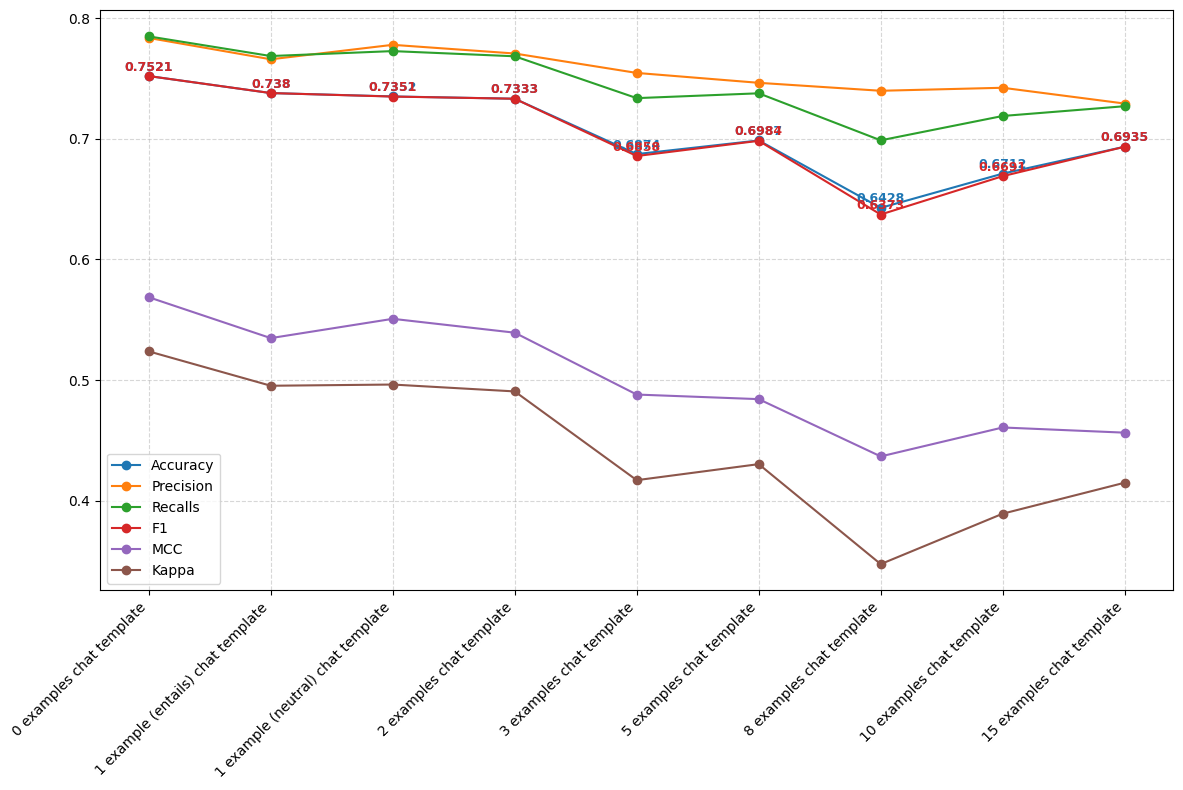

In [5]:
fig, ax = plt.subplots(figsize=(12, 8))

# plot all metrics
metrics_df.plot(kind='line', ax=ax, marker='o')

# set custom x-axis labels
ax.set_xticks(range(len(metrics_df.index)))
ax.set_xticklabels(metrics_df.index, rotation=45, ha='right')

# show grid
ax.grid(True, linestyle='--', alpha=0.5)

# annotate only Accuracy and F1
for metric in ["Accuracy", "F1"]:
    for x, y in enumerate(metrics_df[metric]):
        ax.text(x, y + 0.002, str(y), ha='center', va='bottom', fontsize=9, fontweight='bold', color=ax.get_lines()[list(metrics_df.columns).index(metric)].get_color())

plt.tight_layout()
plt.show()